# TASK 1
## a) Example of poor quality structured data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline
from sklearn.decomposition import PCA
from numpy.linalg import svd

In [3]:
# Example 1
data = pd.DataFrame({
    'Date': ['2023-10-01', '2023-10-01', '2023-10-02', '2023-10-03', '10-04-2023'],
    'Stock Symbol': ['AAPL'] * 5,
    'Price': [150.23, 150.23, np.nan, -120.5, 152.10]
})
print("\nPoor Quality Structured Data:")
print(data)


Poor Quality Structured Data:
         Date Stock Symbol   Price
0  2023-10-01         AAPL  150.23
1  2023-10-01         AAPL  150.23
2  2023-10-02         AAPL     NaN
3  2023-10-03         AAPL -120.50
4  10-04-2023         AAPL  152.10


In [4]:
# Example 2
data = {
    "Customer_ID": [101, 102, None, 104],
    "Name": ["Gabriel", None, "Sana", "Erik"],
    "Age": [25, -1, 37, None],  
    "Purchase_Amount": ["100", "abc", 200, None] 
}

df = pd.DataFrame(data)

print("Poor Quality Structured Data:")
print(df)

Poor Quality Structured Data:
   Customer_ID     Name   Age Purchase_Amount
0        101.0  Gabriel  25.0             100
1        102.0     None  -1.0             abc
2          NaN     Sana  37.0             200
3        104.0     Erik   NaN            None


There are a number of problems with this dataset:
- Missing values (None).
- Incorrect entries (negative age or non-numeric purchase amount, for example).
- Data types are inconsistent.

## b) You can identify low quality structured data by the following conditions:

NaN Values: Important fields like Customer_ID and Name have None, which can cause incomplete analysis.

Rejection of Invalid Values: Age column negative values are impossible both entries like my name in the Purchase_Amount column are useless for calculation.

Feature Data Types Inequality: Mixing strings and numbers within a single column will cause the processing error

Inconsistent Range of Values: There is no standard format or range of values.

## c) Example of poor quality unstructured data

In [5]:
unstructured_data = """
Customer Feedback:
1. Sana: "The product was okay. Delivery took too long."
2. Erik: "Worst service ever! Never buying again."
3. Gabriel: "Good."
4. Mustafa: ""
"""

print("Poor Quality Unstructured Data:")
print(unstructured_data)

Poor Quality Unstructured Data:

Customer Feedback:
1. Sana: "The product was okay. Delivery took too long."
2. Erik: "Worst service ever! Never buying again."
3. Gabriel: "Good."
4. Mustafa: ""



Issues with this unstructured data:

- Lack of standardization (e.g., varying lengths and detail of feedback).
- Missing information (e.g., Mustafa's feedback is empty).
- Ambiguity (e.g., Gabriel's feedback is too vague to interpret).

## d) Good quality data and Unstructured data does not satisfy the following points :

Incompleteness: Insights can be hard to come by when feedback from any customers is absent or empty.

Ambiguity: General replies such as “Good” are meaningless as there are no takeaways for decision making.

Inconsistency: Feedback comes in many different formats and levels of detail, making it difficult to systematically dissect.

Noise: Emotional words like "Worst service ever!" may not be constructive or informative.

# TASK 2

## Yield Curve Modeling (Pakistan)

In [6]:
maturities = np.array([0.25, 0.5, 1, 3, 5, 10, 20])  # In years
yields = np.array([11.82, 12.10, 12.25, 12.30, 12.37, 12.63, 13.10])  # yield values from SBP & Investing.com

def nelson_siegel(m, beta0, beta1, beta2, tau):
    return beta0 + beta1 * (1 - np.exp(-m / tau)) / (m / tau) + beta2 * ((1 - np.exp(-m / tau)) / (m / tau) - np.exp(-m / tau))

params, _ = curve_fit(nelson_siegel, maturities, yields, p0=[10, -2, 2, 2])
nelson_fit = nelson_siegel(maturities, *params)

## Cubic-Spline Fit

In [7]:
cs = CubicSpline(maturities, yields)
spline_fit = cs(maturities)

## Plot Yield Curve

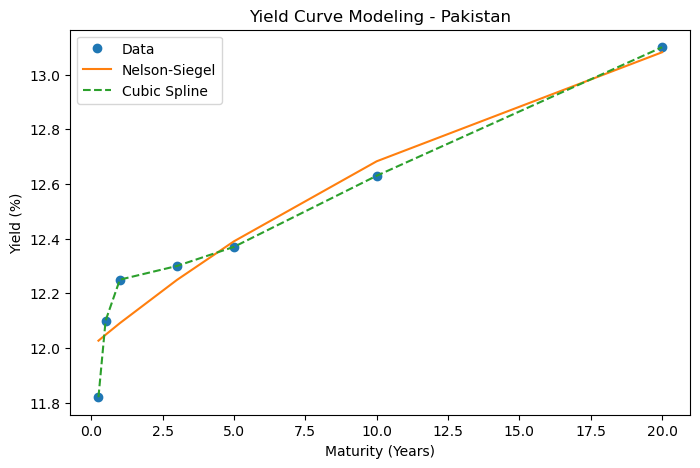

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(maturities, yields, 'o', label='Data')
plt.plot(maturities, nelson_fit, label='Nelson-Siegel')
plt.plot(maturities, spline_fit, '--', label='Cubic Spline')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.title('Yield Curve Modeling - Pakistan')
plt.show()

## 📊 Comparison of Models (Fit & Interpretation)

The parametric and economically-interpretable Nelson-Siegel model provides a fit to the yield curve. It encodes the level, slope, and curvature of the term structure, making it good for both visualization and economic analysis. The model can produce smoother, more stable curves than the projection, particularly where the data is noisy.

This is a non-parametric, piecewise polynomial fit called a Cubic Spline model. This approach has the advantage that it can fit local variability very closely, but it is not economically interpretable and can over-fit with sparse data points.

Fit Quality:

The Nelson-Siegel fit may not go through all the data points but is a good overall fit.

The fitted spline goes through all the points exactly, but it can produce strange shapes of curve between points (when there are not enough maturities).

## 🔢 Interpretation of Nelson-Siegel Parameters

The output Nelson-Siegel parameters estimated by the model are：

Beta0 (Level): The long-term interest rate. It serves as an anchor for the yield curve at long maturities.

Beta1 (Slope): This gives the short-term component. High value means steep curve (short rates much lower than long).

Are going to be similar to the sentences below — ·Beta2 (Curvature): Refers to depicting the medium-run hump in the slope. Guesses greater than na are associated with a strong mid-term peak.

Tau (Decay Factor): This determines the time decay of the slope and curvature components.

These parameters assist us in understanding how the market views the progression of interest rates across the term structure.

## ⚖️Should You Smooth the Yield Curve?

In Module 2 Lesson 4 we mentioned that smoothing data can be unethical if it hides important variations or if it misleads stakeholders about real risks. But generally, yield curve fitting with Nelson-Siegel model is not considered unethical, provided that:

This is a tool that helps to clean and explain the shape of interest rates.

There is transparency around this smoothing, and it is documented.

Analysts admit the model is an approximation and not an exact representation of market rates.

Smoothing becomes dubious if it is carried out with the intent of hiding volatility or misrepresenting trends that could drive investment decisions.

### References (MLA Style)

1. State Bank of Pakistan. "Market Treasury Bills and Pakistan Investment Bonds Rates." Accessed March 21, 2025. [https://www.sbp.org.pk/ecodata/index4.asp](https://www.sbp.org.pk/ecodata/index4.asp).

2. Investing.com. "Pakistan Government Bonds." Accessed March 21, 2025. [https://www.investing.com/rates-bonds/pakistan-government-bonds](https://www.investing.com/rates-bonds/pakistan-government-bonds).